기술 통계 : 수집된 데이터의 특성을 요약하고 설명하는 통계 기법.

중심 경향성 : 데이터 전체를 하나의 대표값으로 요약


    평균값 : 모든 값의 합을 데이터 개수로 나눈 값, 이상치에 민감
    중앙값 : 데이터 크기순 정렬시 가운데 값, 이상치 영향 거의 안받음
    최빈값 : 데이터에서 가장 빈번히 등장하는 값. 범주형 데이터 적용 가능

산포도 : 데이터가 중심 값 중위에 얼마나 퍼져있는지를 나타냄


    범위 : 최댓값과 최솟값의 차이, 이상치에 취약
    분산 : 각 값과 편차를 제곱하여 평균한 값
    표준 편차 : 분산의 제곱근, 데이터와 동일한 단위를 지님
    사분범위 : 제 3사분위에서 제1사분위수를 뺀 값, 이상치에 강건

In [1]:
#numpy : 수치 연산
#pandas : 데이터 프레임 기반 데이터 처리
#matplotlib.pyplot : 데이터 시각화
#seaborn : 통계 기반 데이터 시각화

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.precision', 6) #소수점 이하 6자리까지만 출력

In [4]:
data_url = 'https://raw.githubusercontent.com/codingalzi/code-workout-datasci/refs/heads/master/data/'

In [5]:
#ID특성을 행 인덱스로 지정하면서 데이터셋을 데이터 프레임으로 불러옴
body_df=pd.read_csv(data_url+"body_fat.csv",index_col='ID')

In [6]:
body_df.head()

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
F001,F,37.0,161.4,62.9,32.8
F002,F,26.0,168.1,56.1,31.5
F003,F,39.0,163.4,53.2,25.2
F004,F,30.0,164.1,49.4,21.8
F005,F,44.0,152.9,51.9,24.2


In [7]:
body_df.tail()

,Sex,Age,Height,Weight,Body fat percentage
ID,,,,,
M496,M,48.0,176.4,95.5,29.7
M497,M,75.0,157.4,63.9,34.9
M498,M,58.0,167.3,68.0,15.6
M499,M,53.0,169.9,65.2,17.8
M500,M,30.0,173.7,67.2,20.3


In [8]:
#info() 메서드는 각 열의 데이터 타입과 결측치 여부를 확인한다
body_df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, F001 to M500
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sex                  1000 non-null   str    
 1   Age                  1000 non-null   float64
 2   Height               1000 non-null   float64
 3   Weight               1000 non-null   float64
 4   Body fat percentage  1000 non-null   float64
dtypes: float64(4), str(1)
memory usage: 79.2+ KB


In [9]:
#body fat percentage와 같이 띄어쓰기 포함 긴 열의 이름 간단히 변경
body_df=body_df.rename(columns={"Body fat percentage": 'BFP'})
body_df.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, F001 to M500
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sex     1000 non-null   str    
 1   Age     1000 non-null   float64
 2   Height  1000 non-null   float64
 3   Weight  1000 non-null   float64
 4   BFP     1000 non-null   float64
dtypes: float64(4), str(1)
memory usage: 79.2+ KB


In [10]:
#범주형 특성에 대해 메서드 포함 항목들의 빈도 확인(value_counts())
body_df['Sex'].value_counts()

Sex
F    500
M    500
Name: count, dtype: int64

In [12]:
body_df['Height'].mean() #성인 남녀의 평균 키
body_df['Height'].median() #성인 남녀의 키 중앙값
body_df['Height'].mode() #성인 남녀의 키 최빈값

0    159.1
1    163.1
Name: Height, dtype: float64

In [46]:
#키의 빈도를 확인할 수 있다.
body_df['Height'].value_counts().iloc[:10]

Height
163.1    10
159.1    10
162.5     9
161.0     8
167.3     8
163.7     8
170.2     8
172.8     8
160.5     7
163.2     7
Name: count, dtype: int64

In [56]:
#키 데이터와 키 평균 데이터를 빼 편차를 구한다.
deviation=body_df['Height']-body_df['Height'].mean()
deviation

ID
F001    -3.4117
F002     3.2883
F003    -1.4117
F004    -0.7117
F005   -11.9117
         ...   
M496    11.5883
M497    -7.4117
M498     2.4883
M499     5.0883
M500     8.8883
Name: Height, Length: 1000, dtype: float64

In [57]:
deviation.mean() #편차의 평균값은 항상 0, 아래 결과는 부도 소수점의 한계

np.float64(-1.8189894035458565e-15)

In [58]:
#body_df['Height']에 포함된 키 데이터의 분산은 편차의 제곱에 mean()을 적용해
#구할 수 있다.
(deviation**2).mean()

np.float64(73.00429310999999)

In [60]:
#표본 데이터로만 계산
s2=body_df['Height'].var(ddof=0)
s2

np.float64(73.00429310999999)

In [61]:
#ddof=1로 지정된 기본 옵션은 불편 분산을 계산한다.
#표본을 통한 모집단 분산 예측
body_df['Height'].var()

np.float64(73.07737048048048)

In [62]:
#데이터 프레임의 std() 메서드를 사요하여 표준 편차를 구한다.
s=body_df['Height'].std(ddof=0) #ddof=0을 설정해 편향 분산에 근거한 표준편차를 구함
s

np.float64(8.54425497688359)

In [63]:
# 그렇다면 불편 분산에 근거한 표준 편차는?
body_df['Height'].std()

np.float64(8.548530311140066)

In [64]:
range=body_df['Height'].max()-body_df['Height'].min()
range
#범위는 데이터 최대값과 최소값의 차이를 가리킨다.

np.float64(45.39999999999998)

In [65]:
Q1 = body_df['Height'].quantile(0.25)
Q3 = body_df['Height'].quantile(0.75)
IQR = Q3 - Q1
IQR
#사분범위는 3사분위-1사분위로 중앙값 중심으로 50퍼 데이터가 모인 구간의 크기를 나타낸다.

np.float64(13.025000000000006)

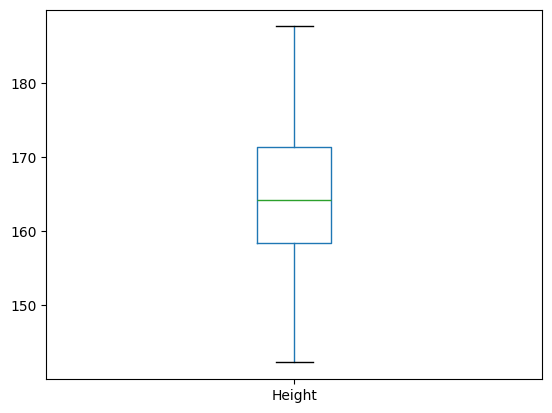

In [67]:
# #박스플롯은
# 이상치
# 3사분위 + 1.5 * 사분범위
# 3,2,1사분위 값 의미 직사각형
# 1사분위 - 1.5 * 사분범위
# 이상치
body_df.boxplot(
    column=['Height'],
    grid=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5)
)
plt.show()

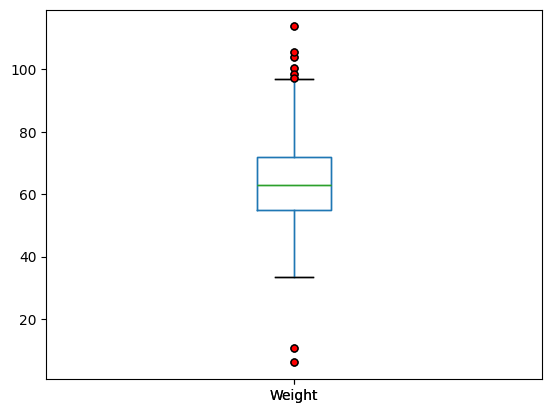

In [69]:
body_df.boxplot(
    column=['Weight'],
    grid=False,
    flierprops=dict(marker='o',markerfacecolor='red',markersize=5)
)

plt.show()

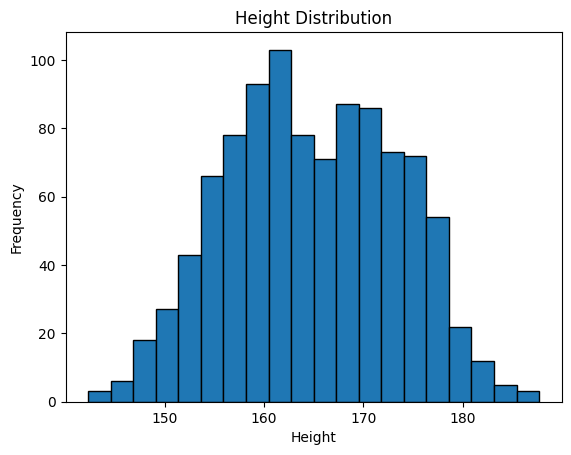

In [70]:
#히스토그램은 빈도를 막대로 표시, 전반적 형태를 보여준다.
body_df['Height'].hist(bins=20, edgecolor='black', grid=False)

plt.xlabel('Height')
plt.ylabel('Frequency')
plt.title('Height Distribution')
plt.show()

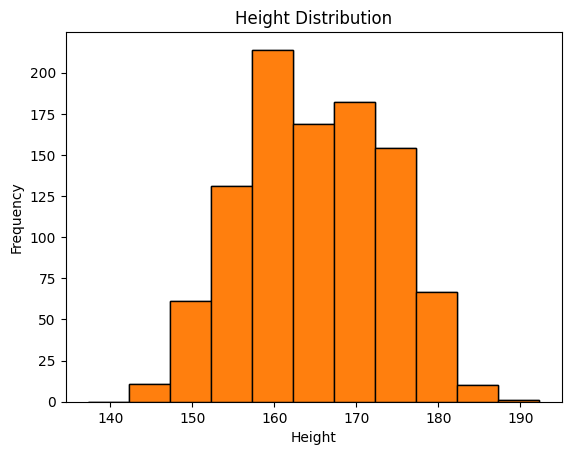

In [75]:
bins=np.arange(body_df['Height'].min()-5,body_df['Height'].max()+5,5)
body_df['Height'].hist(bins=bins, edgecolor='black', grid=False)

plt.xlabel("Height")
plt.ylabel("Frequency")
plt.title("Height Distribution")
plt.show()


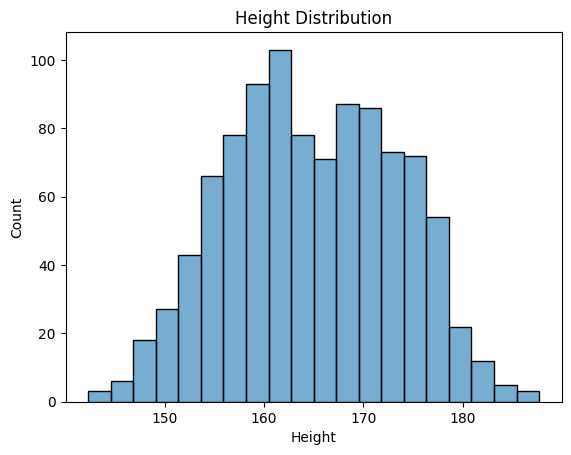

In [76]:
#sns histplot을 활용해 보다 세련된 형태로 손쉽게 파악 가능
sns.histplot(data=body_df,x='Height', bins=20, alpha=0.6)

plt.title('Height Distribution')
plt.show()

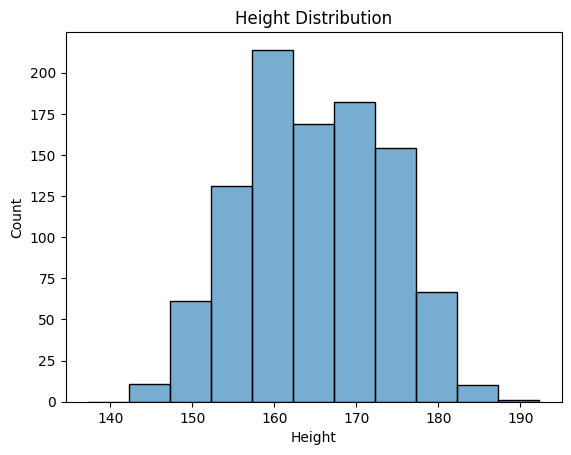

In [77]:
import seaborn as sns

bins = np.arange(body_df['Height'].min() - 5, body_df['Height'].max() + 5, 5)
sns.histplot(data=body_df, x='Height', bins=bins, alpha=0.6)

plt.title('Height Distribution')
plt.show()

In [81]:
#describe()메서드는 데이터의 개수, 평균, 표준편차, 최댓값, 최솟값, 사분위수에
#대한 정보를 담고있는 DF 생성
body_df['Height'].describe()

count    1000.00000
mean      164.81170
std         8.54853
min       142.30000
25%       158.40000
50%       164.30000
75%       171.42500
max       187.70000
Name: Height, dtype: float64

In [82]:
body_df.describe()

,Age,Height,Weight,BFP
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,48.177000,164.81170,64.138600,28.457900
std,15.245002,8.54853,11.983963,7.027338
min,20.000000,142.30000,6.000000,8.200000
25%,35.000000,158.40000,55.075000,23.475000
50%,49.000000,164.30000,62.800000,28.850000
75%,61.000000,171.42500,71.925000,33.500000
max,80.000000,187.70000,113.800000,50.500000


In [83]:
body_df.groupby('Sex').size()

Sex
F    500
M    500
dtype: int64

In [84]:
body_df.groupby('Sex').size()/len(body_df)

Sex
F    0.5
M    0.5
dtype: float64

In [85]:
body_df.groupby('Sex').mean()

,Age,Height,Weight,BFP
Sex,,,,
F,49.030,158.2028,56.0244,31.9302
M,47.324,171.4206,72.2528,24.9856


In [88]:
body_df.groupby('Sex').agg(['mean', 'std', 'min', 'max'])

Age                           Height                           Weight  \
       mean        std   min   max      mean       std    min    max     mean   
Sex                                                                             
F    49.030  14.895935  20.0  79.0  158.2028  5.302243  142.3  172.6  56.0244   
M    47.324  15.554385  20.0  80.0  171.4206  5.536897  154.7  187.7  72.2528   

                                 BFP                        
           std   min    max     mean       std   min   max  
Sex                                                         
F     7.409040   6.0   90.9  31.9302  5.995401  13.9  50.5  
M    10.033957  10.8  113.8  24.9856  6.225675   8.2  44.8

In [90]:
df_double_index = body_df.groupby('Sex').agg(['mean', 'std', 'min', 'max'])
df_double_index.loc[:, ('Age', 'mean')]

Sex
F    49.030
M    47.324
Name: (Age, mean), dtype: float64

In [92]:
body_df.groupby('Sex').agg({'Height':'mean','Weight':'median','BFP':'std'})

,Height,Weight,BFP
Sex,,,
F,158.2028,55.3,5.995401
M,171.4206,71.4,6.225675


In [95]:
body_df.groupby('Sex').filter(lambda g:g['Height'].mean() >=170)
#평균 키가 170이상인 그룹만 남긴다.

,Sex,Age,Height,Weight,BFP
ID,,,,,
M001,M,38.0,177.2,73.4,20.9
M002,M,51.0,175.4,79.3,24.3
M003,M,26.0,175.6,76.1,24.2
M004,M,21.0,176.9,77.6,26.6
M005,M,25.0,177.1,69.1,23.1
...,...,...,...,...,...
M496,M,48.0,176.4,95.5,29.7
M497,M,75.0,157.4,63.9,34.9
M498,M,58.0,167.3,68.0,15.6


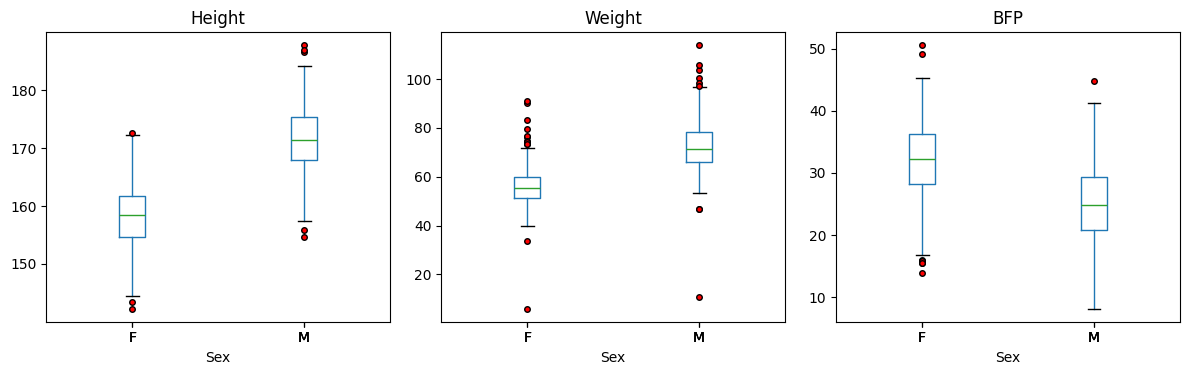

In [96]:
body_df.boxplot(
    column=['Height', 'Weight', 'BFP'],
    by='Sex',
    layout=(1, 3),
    figsize=(12, 4),
    grid=False,
    sharey=False,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=4)
)
plt.suptitle('')
plt.tight_layout()
plt.show()

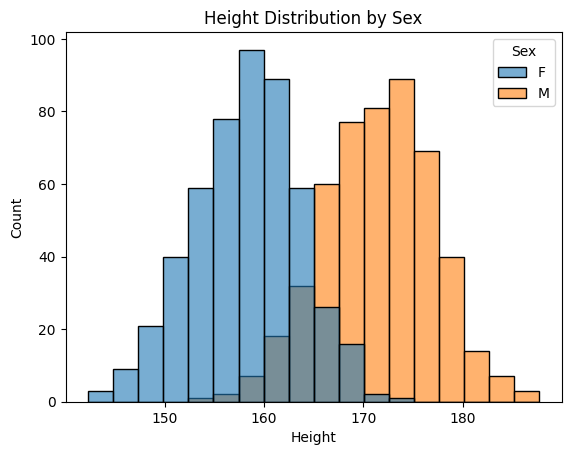

In [97]:
sns.histplot(data=body_df, x='Height', hue='Sex', bins='auto', alpha=0.6)
plt.title('Height Distribution by Sex')
plt.show()

In [98]:
Q1 = body_df['Weight'].quantile(0.25)
Q3 = body_df['Weight'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f'Q1: {Q1},  Q3: {Q3},  IQR: {IQR}')
print(f'하한 울타리: {lower:.2f}')
print(f'상한 울타리: {upper:.2f}')

Q1: 55.075,  Q3: 71.92500000000001,  IQR: 16.85000000000001
하한 울타리: 29.80
상한 울타리: 97.20


In [99]:
weights_df = body_df['Weight']
mask = (weights_df < lower) | (weights_df > upper)
weights_df[mask]

ID
F470      6.0
M042     10.8
M208    100.5
M210    103.9
M218    113.8
M331     98.5
M342     97.4
M360    105.6
Name: Weight, dtype: float64

In [100]:
weights_df.mean()

np.float64(64.13860000000001)

In [101]:
weights_clean = weights_df[~mask]

print(f'이상치 제거 전 평균:  {weights_df.mean():.4f}')
print(f'이상치 제거 후 평균:  {weights_clean.mean():.4f}')
print()
print(f'이상치 제거 전 중앙값: {weights_df.median():.4f}')
print(f'이상치 제거 후 중앙값: {weights_clean.median():.4f}')

이상치 제거 전 평균:  64.1386
이상치 제거 후 평균:  64.0142

이상치 제거 전 중앙값: 62.8000
이상치 제거 후 중앙값: 62.8000


In [102]:
sex_weight_df = body_df[['Sex', 'Weight']]

print('=== 이상치 제거 전 ===')
print(sex_weight_df.groupby('Sex')['Weight'].agg(['mean', 'median']))
print()
print('=== 이상치 제거 후 ===')
print(sex_weight_df[~mask].groupby('Sex')['Weight'].agg(['mean', 'median']))

=== 이상치 제거 전 ===
        mean  median
Sex                 
F    56.0244    55.3
M    72.2528    71.4

=== 이상치 제거 후 ===
          mean  median
Sex                   
F    56.124649    55.3
M    71.999797    71.2


In [103]:
body_df.describe()

,Age,Height,Weight,BFP
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,48.177000,164.81170,64.138600,28.457900
std,15.245002,8.54853,11.983963,7.027338
min,20.000000,142.30000,6.000000,8.200000
25%,35.000000,158.40000,55.075000,23.475000
50%,49.000000,164.30000,62.800000,28.850000
75%,61.000000,171.42500,71.925000,33.500000
max,80.000000,187.70000,113.800000,50.500000


In [104]:
#데이터를 정규화하여 특성 값들의 범위를 통일시키는 기법인 min-max 스케일링과
# 표준화
height_col=body_df[['Height']]
height_minmax=(height_col-height_col.min())/(height_col.max()-height_col.min())
body_df['Height_minmax']=height_minmax
body_df['Height_minmax']

ID
F001    0.420705
F002    0.568282
F003    0.464758
F004    0.480176
F005    0.233480
          ...   
M496    0.751101
M497    0.332599
M498    0.550661
M499    0.607930
M500    0.691630
Name: Height_minmax, Length: 1000, dtype: float64

In [105]:
body_df.describe()

,Age,Height,Weight,BFP,Height_minmax
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,48.177000,164.81170,64.138600,28.457900,0.495852
std,15.245002,8.54853,11.983963,7.027338,0.188294
min,20.000000,142.30000,6.000000,8.200000,0.000000
25%,35.000000,158.40000,55.075000,23.475000,0.354626
50%,49.000000,164.30000,62.800000,28.850000,0.484581
75%,61.000000,171.42500,71.925000,33.500000,0.641520
max,80.000000,187.70000,113.800000,50.500000,1.000000


In [107]:
height_z = (height_col - height_col.mean()) / height_col.std(ddof=0)
body_df['Height_z'] = height_z
body_df['Height_z']

ID
F001   -0.399298
F002    0.384855
F003   -0.165222
F004   -0.083296
F005   -1.394118
          ...   
M496    1.356268
M497   -0.867448
M498    0.291225
M499    0.595523
M500    1.040266
Name: Height_z, Length: 1000, dtype: float64

In [108]:
body_df.describe()

,Age,Height,Weight,BFP,Height_minmax,Height_z
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,48.177000,164.81170,64.138600,28.457900,0.495852,-3.410605e-16
std,15.245002,8.54853,11.983963,7.027338,0.188294,1.000500e+00
min,20.000000,142.30000,6.000000,8.200000,0.000000,-2.634718e+00
25%,35.000000,158.40000,55.075000,23.475000,0.354626,-7.504107e-01
50%,49.000000,164.30000,62.800000,28.850000,0.484581,-5.988819e-02
75%,61.000000,171.42500,71.925000,33.500000,0.641520,7.740055e-01
max,80.000000,187.70000,113.800000,50.500000,1.000000,2.678794e+00


In [109]:
iris_df=pd.read_csv(data_url+'iris.csv')
iris_df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [110]:
iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [111]:
iris_df['petal.length'].mean()

np.float64(3.7580000000000005)

In [112]:
iris_df['sepal.width'].median()

np.float64(3.0)

In [117]:
iris_df['petal.width'].mode()[0]

np.float64(0.2)

In [119]:
Q1=iris_df['sepal.length'].quantile(0.25)
Q3=iris_df['sepal.length'].quantile(0.75)
IQR=Q3-Q1
print(Q1,Q3,IQR)

5.1 6.4 1.3000000000000007


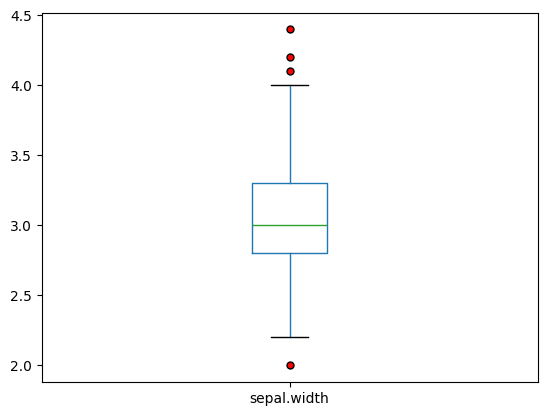

In [123]:
iris_df.boxplot(
    column=['sepal.width'],
    grid=False,
    flierprops=dict(marker='o',markerfacecolor='red', markersize=5),
)
plt.show()

In [126]:
iris_df['petal.width'].var(ddof=0)

np.float64(0.5771328888888888)

In [127]:
iris_df['petal.width'].std(ddof=0)

np.float64(0.7596926279021594)

In [129]:
iris_df['petal.width'].max()-iris_df['petal.width'].min()

np.float64(2.4)

In [132]:
pl=iris_df['petal.length']

In [133]:
iris_df['petal_length_scaled']=(pl-pl.min())/(pl.max()-pl.min())
iris_df[['petal.length','petal_length_scaled']].head()

,petal.length,petal_length_scaled
0,1.4,0.067797
1,1.4,0.067797
2,1.3,0.050847
3,1.5,0.084746
4,1.4,0.067797


In [140]:
sw=iris_df['sepal.width']

iris_df['sepal_width_z']=(sw-sw.mean())/sw.std(ddof=0)
iris_df[['sepal.width','sepal_width_z']].head()

,sepal.width,sepal_width_z
0,3.5,1.019004
1,3.0,-0.131979
2,3.2,0.328414
3,3.1,0.098217
4,3.6,1.249201


In [142]:
Q1=sw.quantile(0.25)
Q3=sw.quantile(0.75)
IQR=Q3-Q1

lowerCase=Q1-(1.5*IQR)
upperCase=Q3+(1.5*IQR)

outliers=iris_df[(sw<lowerCase)|(sw>upperCase)]
outliers

,sepal.length,sepal.width,petal.length,petal.width,variety,petal_length_scaled,sepal_width_z
15,5.7,4.4,1.5,0.4,Setosa,0.084746,3.090775
32,5.2,4.1,1.5,0.1,Setosa,0.084746,2.400185
33,5.5,4.2,1.4,0.2,Setosa,0.067797,2.630382
60,5.0,2.0,3.5,1.0,Versicolor,0.423729,-2.433947


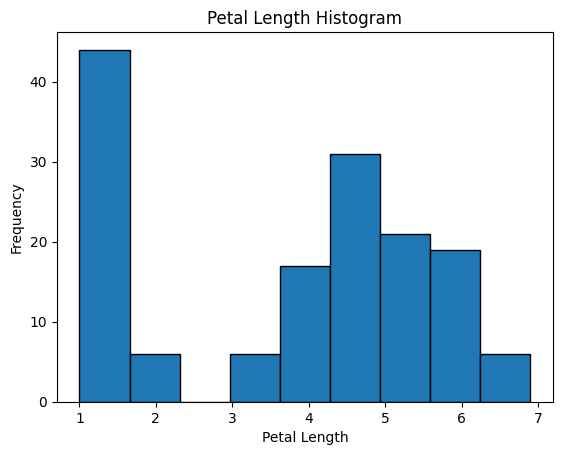

In [143]:
pl=iris_df['petal.length']

plt.hist(pl,bins='auto', edgecolor='black')
plt.xlabel('Petal Length')
plt.ylabel('Frequency')
plt.title('Petal Length Histogram')
plt.show()

In [147]:
varit=iris_df.groupby('variety')

In [148]:
varit.size()

variety
Setosa        50
Versicolor    50
Virginica     50
dtype: int64

In [150]:
varit.mean(numeric_only=True)

,sepal.length,sepal.width,petal.length,petal.width,petal_length_scaled,sepal_width_z
variety,,,,,,
Setosa,5.006,3.428,1.462,0.246,0.078305,0.853263
Versicolor,5.936,2.770,4.260,1.326,0.552542,-0.661432
Virginica,6.588,2.974,5.552,2.026,0.771525,-0.191831


In [155]:
varit['petal.length'].agg(['mean','std','min','max'])

,mean,std,min,max
variety,,,,
Setosa,1.462,0.173664,1.0,1.9
Versicolor,4.260,0.469911,3.0,5.1
Virginica,5.552,0.551895,4.5,6.9


In [156]:
varit['sepal.length'].describe()

,count,mean,std,min,25%,50%,75%,max
variety,,,,,,,,
Setosa,50.0,5.006,0.352490,4.3,4.800,5.0,5.2,5.8
Versicolor,50.0,5.936,0.516171,4.9,5.600,5.9,6.3,7.0
Virginica,50.0,6.588,0.635880,4.9,6.225,6.5,6.9,7.9


In [157]:
sc_weir_df = pd.read_csv(data_url+'sc_weir.csv')
sc_weir_df

,Chl-a,Discharge
0,51,25
1,51,25
2,53,24
3,53,24
4,54,22
...,...,...
95,122,9
96,122,9
97,124,49
98,125,9


In [158]:
sc_weir_arr = sc_weir_df.values

In [159]:
sc_weir_arr.shape

(100, 2)

In [160]:
sc_weir_arr[:10]

array([[51, 25],
       [51, 25],
       [53, 24],
       [53, 24],
       [54, 22],
       [55, 22],
       [57, 21],
       [57, 21],
       [59, 20],
       [60, 20]])

In [164]:
sc_weir_arr[:,1].mean()

np.float64(14.93)

In [165]:
discharge_arr = sc_weir_arr[:, 1]

In [167]:
np.median(discharge_arr)

np.float64(13.0)

In [173]:
vals, counts=np.unique(discharge_arr, return_counts=True)
vals[counts.argmax()]


np.int64(11)

In [174]:
np.percentile(discharge_arr,25)

np.float64(11.0)

In [175]:
np.percentile(discharge_arr,75)

np.float64(16.0)